# Homework 1: Perceptrons

This assignment is due on Gradescope by **11:59pm on Thursday, April 10th**. 
Your solutions to theoretical questions should be done in Markdown with LaTeX directly below the associated question.
Your solutions to computational questions should include any specified Python code and results 
as well as written commentary on your conclusions.
Remember that, while you're welcome to discuss the homework with your classmates at a high level 
**you must write all your code and your solutions on your own**. Before moving on, please refresh yourself by reading our **Academic Honesty Policy** [here](https://canvas.uchicago.edu/courses/63749/assignments/syllabus).

**NOTES**: 

- Do **NOT** load or use any Python packages that are not available in Anaconda with Python 3.12. 
- Some problems with code may be autograded.  If we provide a function API **do not** change it.  If we do not provide a function API then you're free to structure your code however you like. 
- Also for the autograder to work, please **do not** add or remove cells in the notebook
- Submit this Jupyter notebook **both** as a .ipynb file and a pdf to Canvas.  Do not compress either using tar, rar, zip, etc. 

**Please put your name below.**

**Name**:

In [1]:
import math
import pickle
import gzip
import numpy as np
import pandas
import matplotlib.pylab as plt
%matplotlib inline

## [100 points] Problem 1 - Perceptron Training

Consider a binary classification problem on the following dataset:

| x1   | x2         | x3      | y| 
|:------:|:------------:| :-----------:|---:|
|0|0|0|-1|
|0|0|1|1|
|0|1|0|1|
|1|0|0|1|
|0|1|1|-1|
|1|1|0|-1|
|1|0|1|-1|
|1|1|1|1|

We are going to experiment with the Perceptron algorithm in this problem.

### Part 1 [10 points]
Complete the `perceptron_train` function and report the results. Note: for this part you should **not** randomly shuffle the order of the data.

In [2]:
# Do not change - unless needed
data = np.array([
    [0, 0, 0, 1, 0, 1, 1, 1],
    [0, 0, 1, 0, 1, 1, 0, 1],
    [0, 1, 0, 0, 1, 0, 1, 1],
    [-1, 1, 1, 1, -1, -1, -1, 1]
])
data = np.transpose(data)
# Initialize the weights and bias (note that we use a non-standard initialization here).
weights = np.array([0, 0.5, 0.5])
bias = 1

Notice that we are using a non-standard initialization here. 

In [3]:
def perceptron_train(data, weights, bias):
    """
    Train a perceptron algorithm and update weights and bias
    :param data (array): data to train model on
    :param weights (array): initial weights
    :param bias (int): initial bias
    
    :type X: array
    :type y: int
    :rtype: weights (array), bias (int), number of mistakes (int)
    """
    mistakes_count = 0
    for row in data:
        X = np.array(row[:3])
        y = row[-1]
        ### BEGIN SOLUTION
        if y * (np.dot(X, weights) + bias) <= 0:
            weights +=  X * y
            bias += y
            mistakes_count += 1
        ### END SOLUTION
    return weights, bias, mistakes_count

#### Part 1 A [5 points]
Report the weights, bias, and number of mistakes after the first epoch.

In [4]:
### Do not change or remove this code
weights, bias, number_of_mistakes = perceptron_train(data, weights, bias)
print(f'weights: {weights}, bias: {bias}, mistakes: {number_of_mistakes}')

weights: [ 1.  -0.5  0.5], bias: 0, mistakes: 5


In [5]:
# for grading - ignore
### BEGIN HIDDEN TESTS
assert (weights == np.array([ 1. , -0.5,  0.5])).all()
assert bias == 0
assert number_of_mistakes == 5
### END HIDDEN TESTS

#### Part 1 B [5 points]:
Run the perceptron training for 50 more epochs with the updated weights and report the weights, bias and number of mistakes.

In [6]:
epochs = 50
for i in range(epochs):
    ### BEGIN SOLUTION
    weights, bias, number_of_mistakes = perceptron_train(data, weights, bias)
    ### END SOLUTION
print(f'weights: {weights}, bias: {bias}, mistakes: {number_of_mistakes}')

weights: [1.  0.5 0.5], bias: -1, mistakes: 4


In [7]:
# for grading - ignore
### BEGIN HIDDEN TESTS
assert (weights == np.array([ 1. , 0.5,  0.5])).all()
assert bias == -1
assert number_of_mistakes == 4
### END HIDDEN TESTS

### Part 2 [10 points] 
Imagine that your Perceptron classifier is not perfect after the first epoch. Is it possible that your Perceptron classifier would 
ever perfectly classify all training examples after more epochs of the Perceptron Algorithm?

Clearly explain your reasoning. Recall from CAPP 271 that you can use an example to show that something is possible.

**Solution:** Yes. When the data is linearly separable the Perceptron algorithm is guaranteed to eventually find a perfect classifier (by the Perceptron convergence theorem).

### Part 3 [10 points] 
Does the Perceptron classifier always make the same number of mistakes after the first epoch if the data is presented in a different randomized order? 

Clearly explain your reasoning. Again, recall from CAPP 271 that you can use a counterexample to show that something isn't always true.

**Solution:** No. The weights and bias get updated accordingly, thereby changing the prediction.

###  Part 4 [45 Points]:  Perceptron Classifier on random generated data

Update the Perceptron Learning Algorithm to explore the convergence on linearly separable simulated data sets with particular properties. Take a look at the `Perceptron` class below.

In [16]:
class Perceptron:
    """
    Class to fit a perceptron classifier to simulated data
    """

    def __init__(self, n=100, margin=0.1, X=None, y=None, random_state=1241):
        """
        Initializes Perceptron class.  Generates training data and sets parameters. 

        :param n (int): the number of training examples
        :param margin (float): the margin between decision boundary and data
        :param random_state: seed for random number generator 
        :param X (array): Input training features.  Only used for unit testing. 
        :param y (array): Input training labels.  Only used for unit testing. 
        """
        # initalize random seed
        np.random.seed(random_state)

        # initialize parameters
        self.n, self.M = n, margin

        # generate random simulated data
        self.X_train, self.y_train = self.gen_data()

        # only used for unit tests
        if X is not None and y is not None:
            self.X_train, self.y_train, self.n = X, y, X.shape[0]

        # initialize weights and bias
        self.w = np.array([1.0, 0.0])
        self.b = 0

        # initialize total mistake counter
        self.num_mistakes = 0

    def train(self, max_epochs=100):
        """
        Runs the Perceptron Algorithm until all training data is correctly classified. 

        :param max_epochs (int): Maximum number of epochs to perform before stopping.
        """

        ### BEGIN SOLUTION
        epoch_mistakes = 1
        ind_list = list(range(self.n))
        epoch_ctr = 0
        while epoch_mistakes > 0 and epoch_ctr < max_epochs:
            epoch_mistakes = 0
            np.random.shuffle(ind_list)
            for ind in ind_list:
                if self.y_train[ind] * (np.dot(self.X_train[ind, :], self.w) + self.b) <= 0:
                    self.num_mistakes += 1
                    epoch_mistakes += 1
                    self.w += self.y_train[ind] * self.X_train[ind, :]
                    self.b += self.y_train[ind]
            epoch_ctr += 1
        ### END SOLUTION

    def plot_model(self, decision_boundary=False):
        """
        Plots the simulated data and the learned decision boundary
        
        :param decision_boundary (bool): whether to plot the decision boundary
        """
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
        colors = ["steelblue" if yi == -
                  1 else "#a76c6e" for yi in self.y_train]
        ax.scatter(self.X_train[:, 0], self.X_train[:, 1], color=colors, s=75)
        if decision_boundary:
            ### BEGIN SOLUTION
            xplot = np.linspace(-1, 1, 100)
            yplot = -(self.b + self.w[0] * xplot) / self.w[1]
            ax.plot(xplot, yplot, color="black", lw=2)
            ### END SOLUTION
        ax.grid(alpha=0.25)
        ax.set_xlabel(r"$x_1$", fontsize=16)
        ax.set_ylabel(r"$x_2$", fontsize=16)
        return fig

    def gen_data(self):
        """
        Generate random linearly separable data with given margin. 
        Note: You should not need to change this function 
        """
        flip = np.random.choice([-1, 1])
        pos_x1 = np.random.uniform(-1 / np.sqrt(2), 1 / np.sqrt(2), int(self.n / 2))
        pos_x2 = np.random.uniform(
            self.M + flip * 0.1, 1 / np.sqrt(2), int(self.n / 2))
        pos_x2[-1] = self.M + flip * 0.1
        neg_x1 = np.random.uniform(-1 / np.sqrt(2), 1 / np.sqrt(2), int(self.n / 2))
        neg_x2 = np.random.uniform(-1 / np.sqrt(2), -
                                   self.M + flip * 0.1, int(self.n / 2))
        neg_x2[-1] = -self.M + flip * 0.1
        X = np.concatenate((np.column_stack((pos_x1, pos_x2)),
                            np.column_stack((neg_x1, neg_x2))))
        X = np.dot(X, np.array(
            [[np.cos(np.pi / 6), np.sin(np.pi / 6)], [-np.sin(np.pi / 6), np.cos(np.pi / 6)]]))
        y = np.array([+1] * int(self.n / 2) + [-1] * int(self.n / 2))
        rand_order = np.random.choice(
            range(self.n), replace=False, size=self.n)
        return X[rand_order], y[rand_order]

#### Part 4 A [10 points]
The `Perceptron` class above has the capability of generating its own training data with certain properties. Execute the cell below to generate $n=100$ simulated training examples and plot them. Experiment with the `margin` parameter (good values to try are between $0.01$ and $0.4$). Explain what the `margin` parameter is doing.

/var/folders/0_/4xyfxxmx3fs1kq_8kbmg2rgm0000gn/T/ipykernel_19990/3640994462.py:72: RuntimeWarning: divide by zero encountered in divide
  yplot = -(self.b + self.w[0] * xplot) / self.w[1]


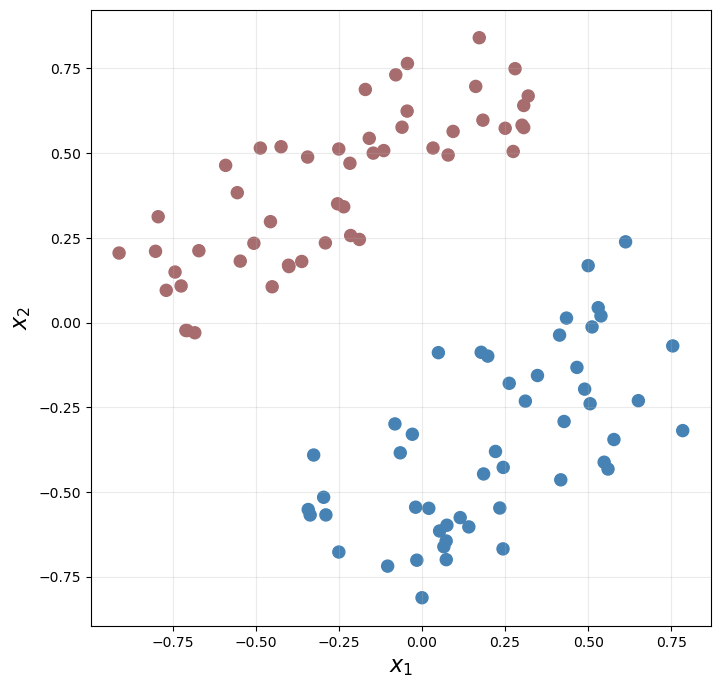

In [18]:
margin = 0.2 # subject to experiment
perc = Perceptron(n=100, margin=margin)
fig = perc.plot_model(decision_boundary=True)
fig

**Solution:** `margin` means the distance from the closest training data to the decision boundary used to generate data.

#### Part 4 B [20 points] 
Modify the `train` method in the `Perceptron` class to perform the Perceptron Learning Algorithm and learn weights ${\bf w}$ and bias $b$ that perfectly classify the linearly separable training data. Your implementation should:

- Visit all training examples in a random shuffled order over each training epoch. (**Note:** np.random.shuffle() will be helpful here)
- Terminate when you finish an epoch without making a single classification error or when you hit the maximum number of epochs.
- Use the `self.num_mistakes` counter to count the total number of classification errors over the entire training process. (**Note:** You should also have a seperate counter variable for keeping track of mistakes within each epoch.)


Notes:

You should **not** use Scikit-Learn's Perceptron object in your solution.
It's a good idea to implement a stopping criterion based on the `max_epochs` parameter as the first step. Later we'll look at training sets that will terminate on their own, but implementing a stopping mechanism will save you some pain in the development process.
Do not change the initial guess for the weights and bias. These values were chosen to match the example done in lecture for the unit tests.

In [10]:
from tests import tests
tests.run_test_suite('prob 1.4B', Perceptron)

TestNegMistake (tests.tests.TestPerceptron.TestNegMistake) ... ok
TestPosMistake (tests.tests.TestPerceptron.TestPosMistake) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.003s

OK


#### Part 4 C [15 points]
Modify the `plot_model` method so that it plots the learned decision boundary with the training data. Demonstrate that your method is working by training a perceptron with a margin of your choice and displaying the resulting plot. What is the equation of the learned decision boundary? Use symbols not numbers (i.e., use Latex).


**Solution:** The decision boundary is the line defined by ${\bf w}^T{\bf x} + b = 0$. With two features, this can be described as

$$w_1x_1 + w_2x_2 + b = 0 \quad \quad \Leftrightarrow \quad \quad x_2 = -\frac{w_1}{w_2}x_1 - \frac{b}{w_2} $$


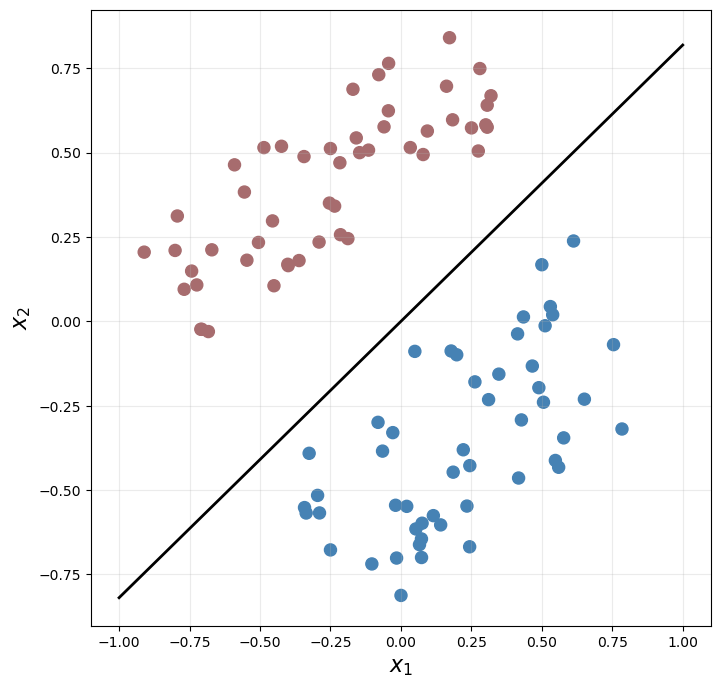

In [19]:
perc = Perceptron(n=100, margin=0.2)
perc.train()
fig = perc.plot_model(decision_boundary=True)
fig

### Part 5 [25 points]

An important theorem states that, if you train a perceptron on linearly separable training data with margin $M > 0$ and each training point satisfies $\|{\bf x}\|_2 \leq 1$ then the Perceptron algorithm will complete after making at most $1/M^2$ classification mistakes.

Numerically verify this theorem by doing the following: 
- Train multiple Perceptrons with $n = 100$ and different margins ($M=0.3, 0.1, 0.01, 0.001,$ and $0.0001$).
- Produce a log-log plot with $1/M$ on the horizontal axis and the total numbers of mistakes on the vertical axis. 
- On the same set of axes, plot the theoretical upper bound on the number of training mistakes.

Hint: The computed number of mistakes should be below the upper bound $1/M^2$ stated in the theorem. If it is not, there is probably something wrong with your code. 

Often we run multiple simulations and compute an averaged number of total mistakes for each margin, but it is fine if you only do one simulation for each margin value.

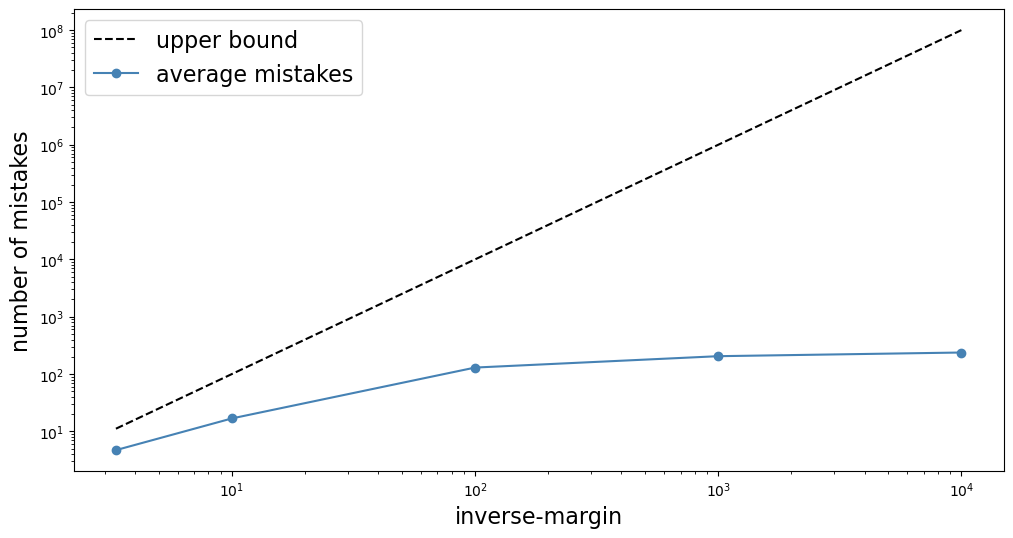

In [21]:
margins = np.array([0.3, 0.1, 0.01, 0.001, 0.0001])
avg_mistakes = np.zeros_like(margins)
# Here we run 20 simulations, but 1 is fine too
num_sims = 20
for ii, margin in enumerate(margins):
    for runs in range(num_sims): 
        perc = Perceptron(margin=margin, random_state=ii+runs)
        perc.train(max_epochs=100)
        avg_mistakes[ii] += perc.num_mistakes
    avg_mistakes[ii] /= num_sims
    
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
ax.loglog(1 / margins, 1 / margins**2, color="black", ls="--", label="upper bound")
ax.loglog(1 / margins, avg_mistakes, marker="o", color="steelblue", label="average mistakes")
ax.legend(loc="upper left", fontsize=16)
ax.set_xlabel("inverse-margin", fontsize=16)
ax.set_ylabel("number of mistakes", fontsize=16)
fig

### Optional survey.
***

Please fill out this anonymous [survey](https://docs.google.com/forms/d/e/1FAIpQLSdmCXMKyP5THhaH_FU7-elaxd7Yf0vsyX2Tf5XMbz43kc1Apw/viewform?usp=header) if you wish to share your feedback for how to improve the course.

**Acknowledgment** : Chris Ketelsen